In [1]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
labels = ['airplane','automobile','bird','cat','deer','dog','frog',
         'horse','ship','truck']

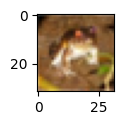

In [9]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])

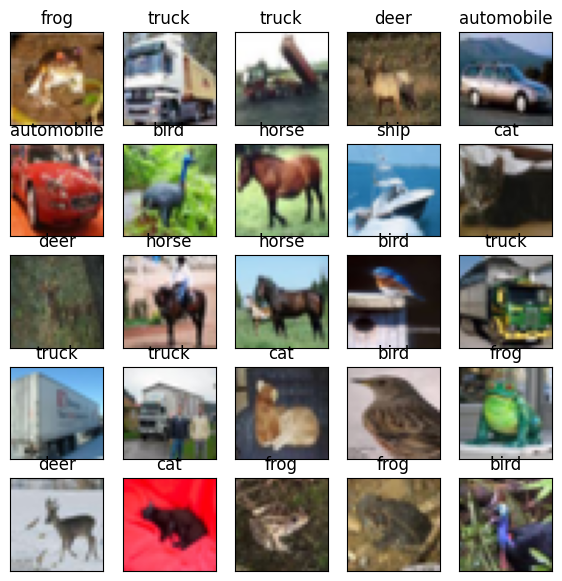

In [13]:
plt.figure(figsize=(7,7))
for i in range(25):
    plt.subplot(5,5,i+1) 
    plt.imshow(x_train[i])
    plt.title(labels[y_train[i][0]])
    plt.xticks([]); plt.yticks([]);

#### Build the model

In [15]:
model = Sequential()

model.add(Input(shape=(32,32,3)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

2026-06-10 09:18:50.704732: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
model.compile(loss='sparse_categorical_crossentropy', 
             optimizer='adam', metrics=['accuracy'])

In [17]:
model.fit(x_train, y_train, epochs=10, batch_size=10)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 67s 13ms/step - accuracy: 0.2088 - loss: 2.6824
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.4107 - loss: 1.6201
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.4768 - loss: 1.4745
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.5121 - loss: 1.3822
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.5438 - loss: 1.3083
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.5538 - loss: 1.2776
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.5809 - loss: 1.2107
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.5966 - loss: 1.1697
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.6152 - loss: 1.1282
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.6282 - loss: 1.0904


In [18]:
model.evaluate(x_test, y_test, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.5262 - loss: 1.4382


[1.430860161781311, 0.5271000266075134]

#### Predict on new data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


'horse'

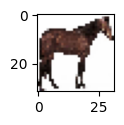

In [23]:
new = cv2.imread('images/horse.webp')
new = cv2.cvtColor(new, cv2.COLOR_BGR2RGB)
new = cv2.resize(new, (32,32))
plt.figure(figsize=(1,1))
plt.imshow(new)
new = new.reshape(1,32,32,3) 
result = model.predict(new) 
result = result.argmax()
labels[result]